In [1]:
"""
Imports

"""

import uproot
import awkward as ak
import argparse
import logging
from tqdm import tqdm
from pathlib import Path
import os
import numpy as np

import torch

from torch.utils.data import IterableDataset

import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import EdgeConv, global_mean_pool

import h5py
import torch.nn.functional as F
#from torch.utils.data import Dataset, DataLoader, random_split
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from torch.cuda.amp import GradScaler, autocast
from livelossplot import PlotLosses

from torch.utils.data import Dataset, DataLoader, random_split

from torch_geometric.loader import DataLoader

import sys

sys.path.append('/global/cfs/cdirs/m4474/aneek/particlemind_aneek')

from src.data.augmentation import *
from src.data.dataset import *
from src.models.gnn import *
from src.models.contrastive_learning import *



/global/homes/a/aneekj02/.conda/envs/colliderml-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:


"""
Loading ColliderML data

"""

from colliderml.core import load_tables, collect_tables


## ttbar data
cfg1 = {
    "dataset_id": "CERN/ColliderML-Release-1",
    "channels": "ttbar",
    "pileup": "pu0",
    "objects": ["calo_hits"],
    "split": "train",
    "lazy": False,
    "max_events": 6400,
    "data_dir":"/pscratch/sd/a/aneekj02/colliderml-data"
}
tables1 = load_tables(cfg1)
frames1 = collect_tables(tables1)

calo_hits1 = frames1["calo_hits"][0:3200]


## dihiggs data
cfg2 = {
    "dataset_id": "CERN/ColliderML-Release-1",
    "channels": "dihiggs",
    "pileup": "pu0",
    "objects": ["calo_hits"],
    "split": "train",
    "lazy": False,
    "max_events": 6400,
    "data_dir":"/pscratch/sd/a/aneekj02/colliderml-data"
}
tables2 = load_tables(cfg2)
frames2 = collect_tables(tables2)

calo_hits2 = frames2["calo_hits"][0:3200]


## ggf data
cfg3 = {
    "dataset_id": "CERN/ColliderML-Release-1",
    "channels": "ggf",
    "pileup": "pu0",
    "objects": ["calo_hits"],
    "split": "train",
    "lazy": False,
    "max_events": 6400,
    "data_dir":"/pscratch/sd/a/aneekj02/colliderml-data"
}
tables3 = load_tables(cfg3)
frames3 = collect_tables(tables3)

calo_hits3 = frames3["calo_hits"][0:3200]

import polars as pl

# Concatenate
#combined = pl.concat([calo_hits1, calo_hits2, calo_hits3])
#combined = pl.concat([calo_hits1, calo_hits2])

# Shuffle rows
#combined = combined.sample(fraction=1.0, with_replacement=False, seed=42)

#print(combined.shape)
#print(combined.head())

#calo_hits = combined





"""
Data Preprocessor

"""

class ColliderMLHits(IterableDataset):
    def __init__(
        self, calo_hits, split, shuffle_files=False, train_fraction=0.8):
        """
        Initialize the dataset.

        Args:
            calo_hits : calo_hit data for events.
            shuffle_files (bool): Whether to shuffle the order of parquet files.
        """
        
        self.calo_hits = calo_hits
        self.shuffle_files = shuffle_files
        

        self.split = split
        if self.split is not None:
            split_index = int(len(self.calo_hits) * train_fraction)
            if self.split == "train":
                self.calo_hits = self.calo_hits[:split_index]
            elif self.split == "val":
                self.calo_hits = self.calo_hits[split_index:]

        if self.shuffle_files:
            self.shuffle_shards()

    def __len__(self):
        """
        Return the number of events in the dataset.
        """
        return len(self.calo_hits) 

    def shuffle_shards(self):
        """
        Shuffle the events in calo_hits
        """
        random.shuffle(self.calo_hits)

    def __iter__(self):
        logger = logging.getLogger(__name__)
        self.sample_counter = 0  # Reset sample counter for each iteration or each epoch
        #worker_info = torch.utils.data.get_worker_info()
        

        
        data = self.calo_hits
        
        for event_i in range(len(self.calo_hits)):

            data_i = data[event_i]

            calo_hit_features = np.column_stack(
                (
                    data_i['x'].to_numpy()[0],
                    data_i['y'].to_numpy()[0],
                    data_i['z'].to_numpy()[0],
                    data_i['total_energy'].to_numpy()[0]

                )
            )

            f_i = len(data_i['x'].to_numpy()[0]) if len(data_i['x'].to_numpy()[0])<8000 else 8000

            yield {

                "calo_hit_features": calo_hit_features

            }
         


"""

Preparing dataset

"""



#dataset_train = ColliderMLHits(calo_hits, "train", shuffle_files=False, train_fraction=0.0)
#dataset_val = ColliderMLHits(calo_hits, "val", shuffle_files=False, train_fraction=0.0)

hits_ttbar = ColliderMLHits(calo_hits1, "train", shuffle_files=False, train_fraction=1.0)
hits_dihiggs = ColliderMLHits(calo_hits2, "train", shuffle_files=False, train_fraction=1.0)
hits_ggf = ColliderMLHits(calo_hits3, "train", shuffle_files=False, train_fraction=1.0)


In [3]:
import numpy as np

def bin_points_to_grid(x, y, v, x_min, x_max, y_min, y_max, nx, ny, cutoff=0.0):
    """
    Bin points (x, y) with values v onto a 2D grid by summing values
    of points falling into each cell.

    Parameters
    ----------
    x, y, v : array-like, shape (N,)
        Coordinates and values of the N points.
    x_min, x_max : float
        Range of the grid in x.
    y_min, y_max : float
        Range of the grid in y.
    nx, ny : int
        Number of grid cells along x and y.

    Returns
    -------
    grid : ndarray, shape (ny, nx)
        Summed values per cell. grid[i, j] corresponds to the cell
        spanning y_edges[i]:y_edges[i+1] and x_edges[j]:x_edges[j+1].
    x_edges : ndarray, shape (nx+1,)
        Bin edges along x.
    y_edges : ndarray, shape (ny+1,)
        Bin edges along y.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    v = np.asarray(v, dtype=float)

    if not (len(x) == len(y) == len(v)):
        raise ValueError("x, y, v must have the same length")

    x_edges = np.linspace(x_min, x_max, nx + 1)
    y_edges = np.linspace(y_min, y_max, ny + 1)

    # weights=v makes histogram2d SUM v instead of counting points
    grid_T, xe, ye = np.histogram2d(
        x, y, bins=[x_edges, y_edges], weights=v
    )

    # histogram2d returns shape (nx, ny) indexed [x_bin, y_bin];
    # transpose to the conventional image/grid layout (ny, nx) = [row=y, col=x]

    grid = grid_T.T

    x_centers = (xe[:-1] + xe[1:]) / 2
    y_centers = (ye[:-1] + ye[1:]) / 2
    X_centers, Y_centers = np.meshgrid(x_centers, y_centers)  # shape (ny, nx) each

    mask = grid > cutoff

    # .ravel() / boolean masking already gives 1D; np.asarray + dtype makes it explicit
    cell_centers_x = np.asarray(X_centers[mask], dtype=float).ravel()
    cell_centers_y = np.asarray(Y_centers[mask], dtype=float).ravel()
    cell_values    = np.asarray(grid[mask], dtype=float).ravel()

    return grid, xe, ye, cell_centers_x, cell_centers_y, cell_values


    
    

Size of original point cloud: 9472; Size of cumulative point cloud: 645


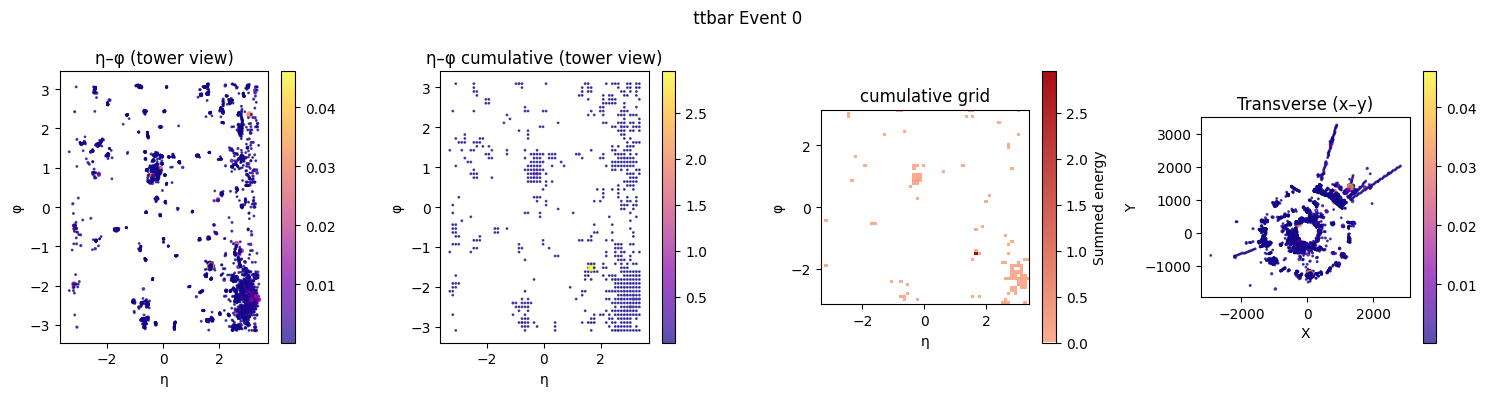

Size of original point cloud: 16636; Size of cumulative point cloud: 742


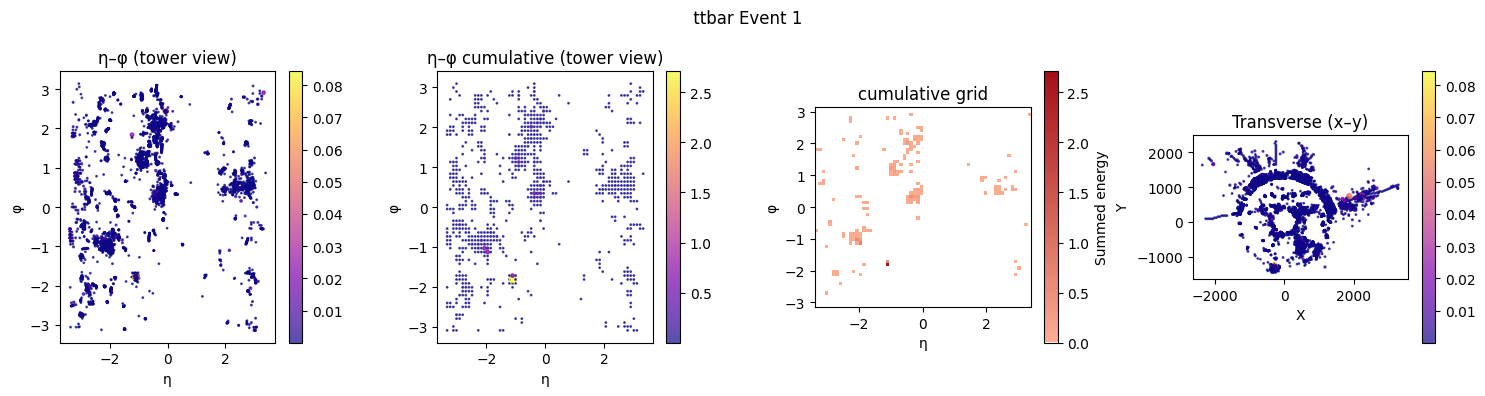

Size of original point cloud: 19814; Size of cumulative point cloud: 954


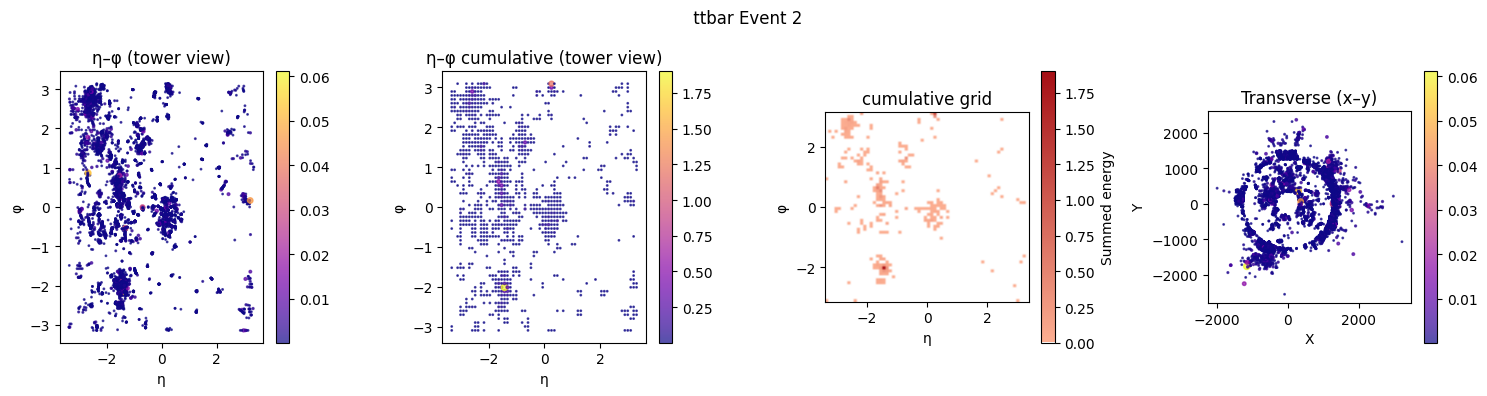

Size of original point cloud: 21088; Size of cumulative point cloud: 1225


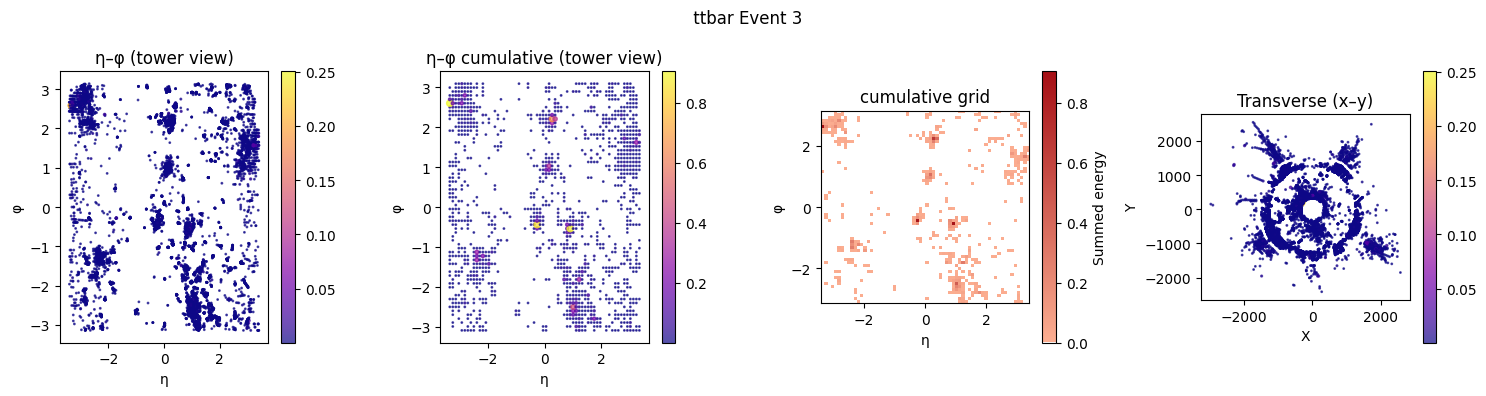

Size of original point cloud: 12553; Size of cumulative point cloud: 849


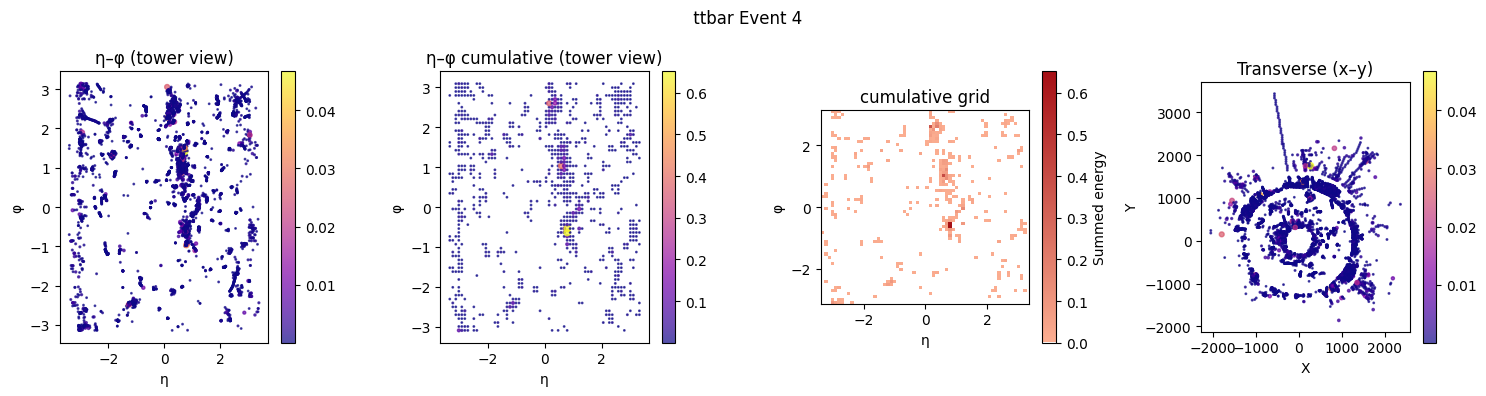

Size of original point cloud: 15018; Size of cumulative point cloud: 814


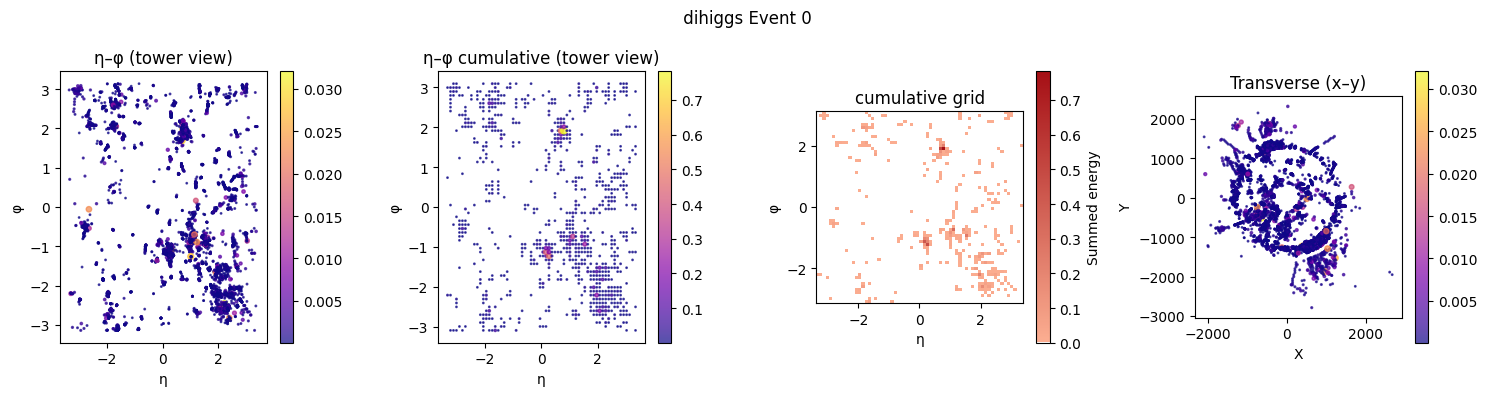

Size of original point cloud: 19701; Size of cumulative point cloud: 1462


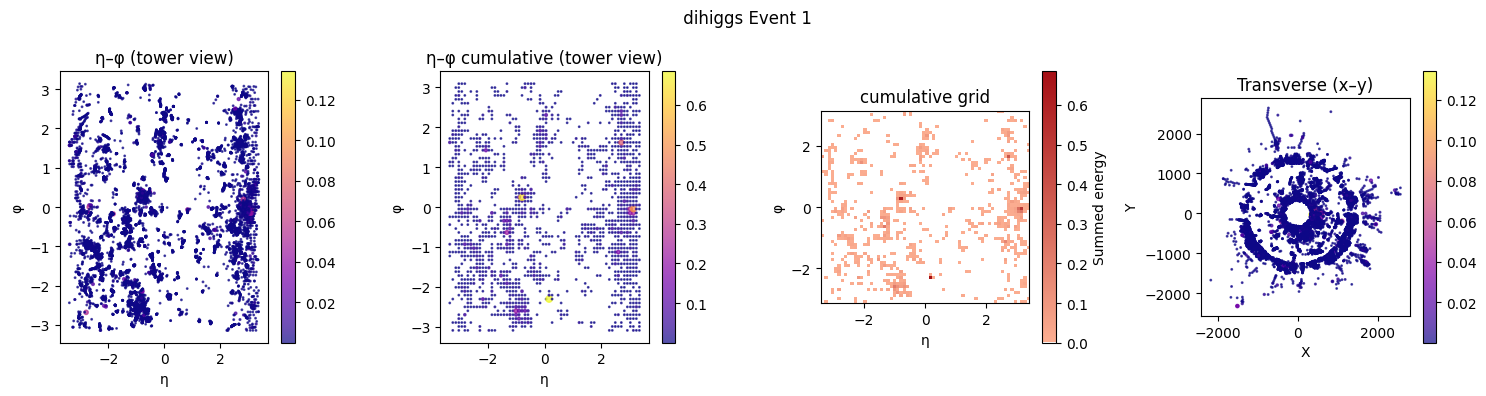

Size of original point cloud: 23244; Size of cumulative point cloud: 1713


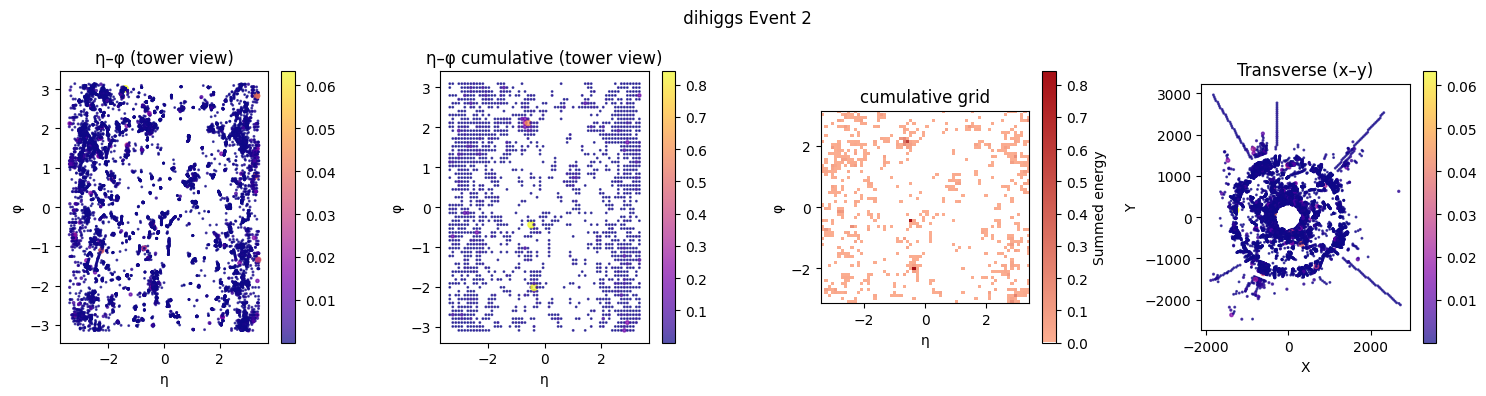

Size of original point cloud: 24748; Size of cumulative point cloud: 1355


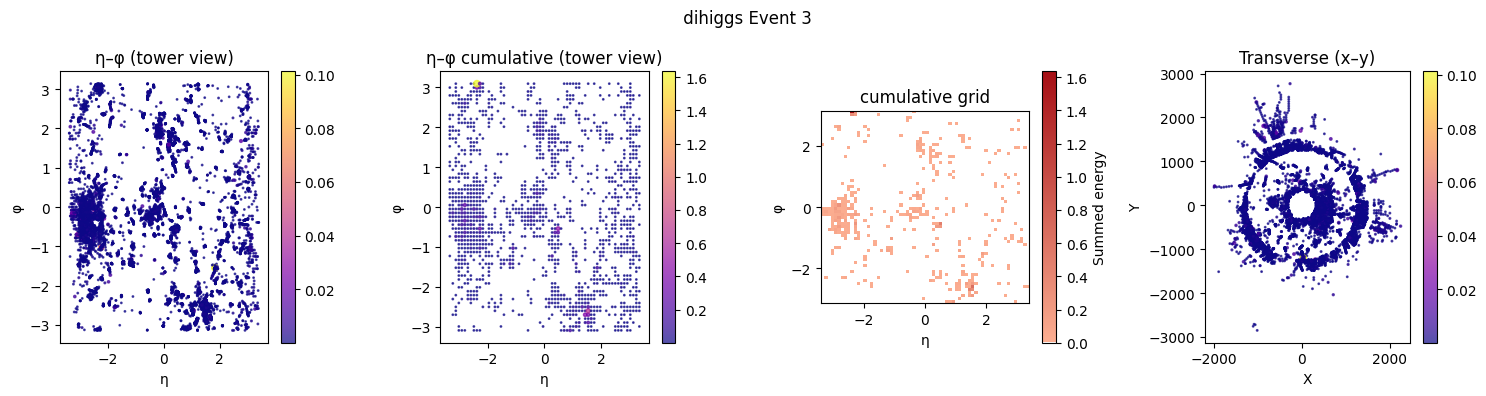

Size of original point cloud: 24093; Size of cumulative point cloud: 1615


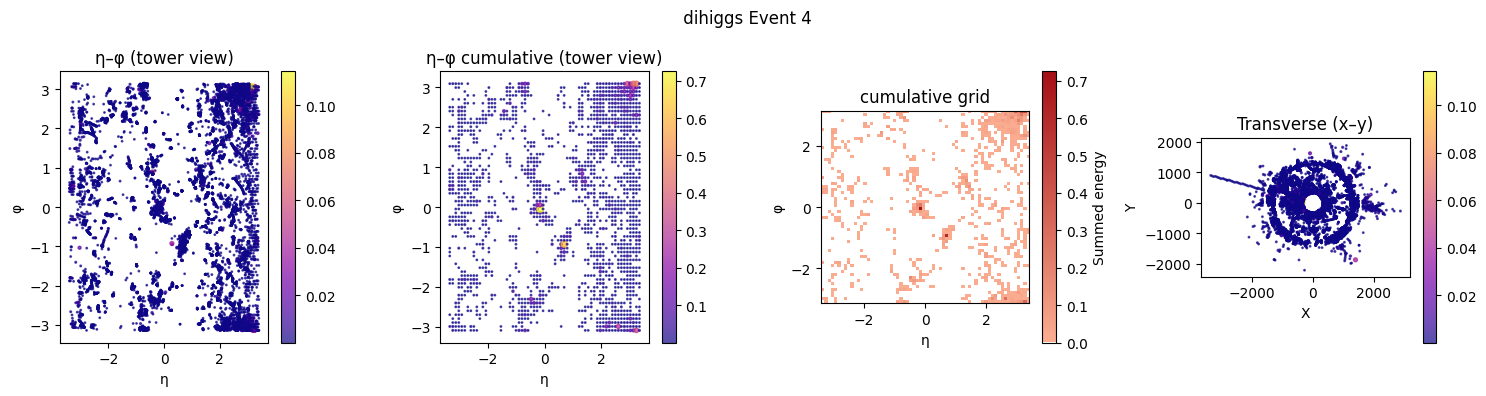

Size of original point cloud: 13350; Size of cumulative point cloud: 1186


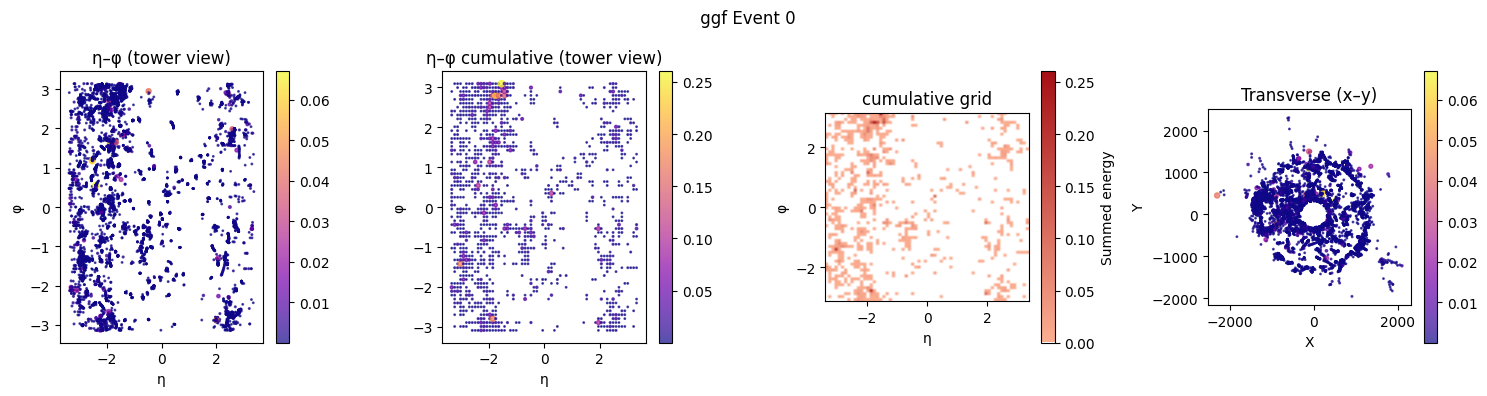

Size of original point cloud: 12632; Size of cumulative point cloud: 984


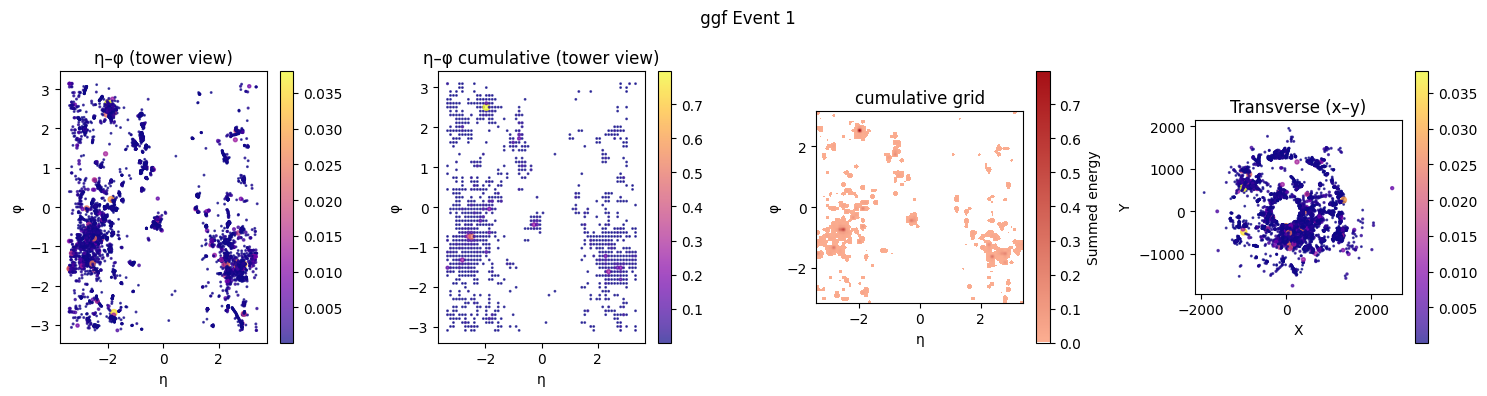

Size of original point cloud: 15536; Size of cumulative point cloud: 1330


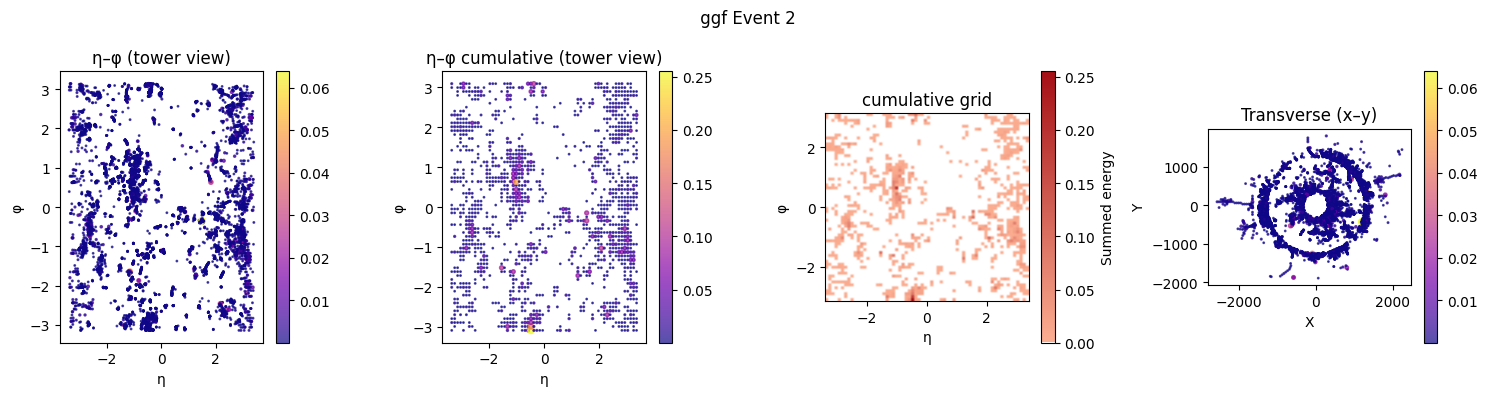

Size of original point cloud: 25135; Size of cumulative point cloud: 1968


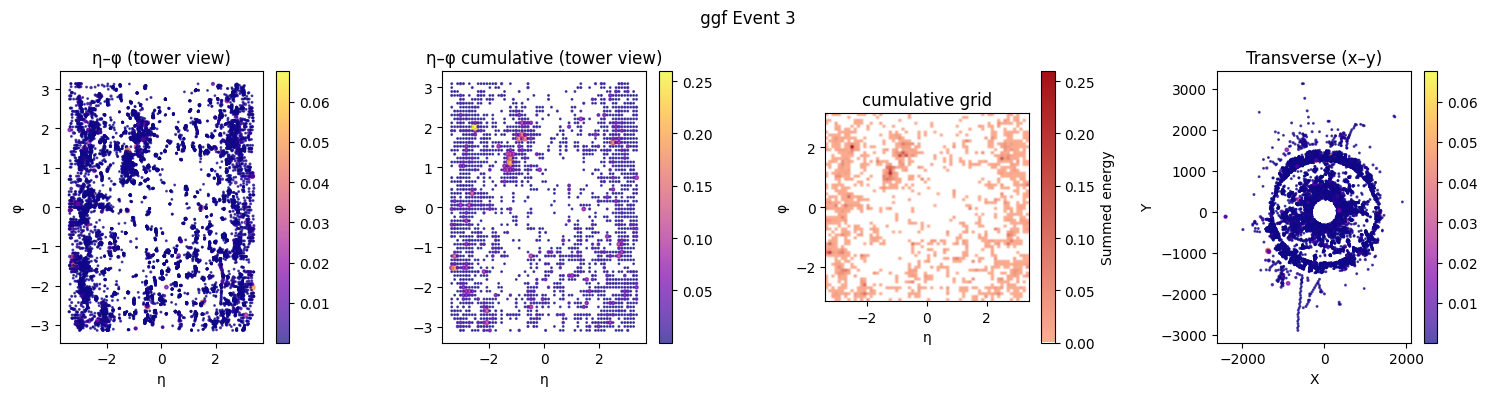

Size of original point cloud: 26521; Size of cumulative point cloud: 1767


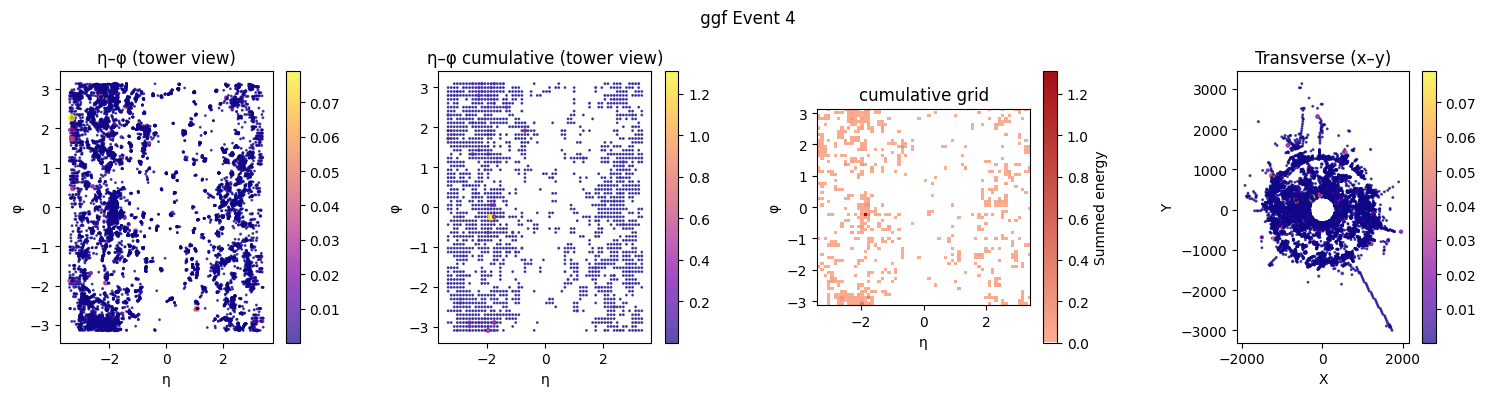

In [15]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

def plot_projections(event, title=""):
    hits = event["calo_hit_features"]
    x, y, z, E = hits[:, 0], hits[:, 1], hits[:, 2], hits[:, 3]

    # Cylindrical coordinates
    r   = np.sqrt(x**2 + y**2)
    phi = np.arctan2(y, x)
    eta = -np.log(np.tan(np.arctan2(r, np.abs(z)) / 2)) * np.sign(z)

    fig, axes = plt.subplots(1, 4, figsize=(15, 4))

    fig.suptitle(title)

    from matplotlib.colors import LinearSegmentedColormap
    
    cmap_hard_start = LinearSegmentedColormap.from_list(
    'hard_start_reds',
    [
        (0.0, 'white'),
        (1e-17, '#fcae91'),   # jump almost immediately to a visible color
        (1.0, '#a50f15'),    # then gradual to deep red
    ]
)

    # η-φ (classic detector view)
    sc0 = axes[0].scatter(eta, phi, c=E, cmap='plasma', s=E/E.max()*20+1, alpha=0.7)
    axes[0].set_xlabel('η'); axes[0].set_ylabel('φ')
    axes[0].set_title('η–φ (tower view)'); plt.colorbar(sc0, ax=axes[0])

    grid_cell, eta_grid, phi_grid, eta_n, phi_n, E_n = bin_points_to_grid(eta, phi, E, np.min(eta), np.max(eta), np.min(phi), np.max(phi), 64, 64)


    

    sc1 = axes[1].scatter(eta_n, phi_n, c=E_n, cmap='plasma', s=E_n/E_n.max()*20+1, alpha=0.7)
    axes[1].set_xlabel('η'); axes[1].set_ylabel('φ')
    axes[1].set_title('η–φ cumulative (tower view)'); plt.colorbar(sc1, ax=axes[1])

    print(f'Size of original point cloud: {len(E)}; Size of cumulative point cloud: {len(E_n)}')

    from matplotlib.colors import LinearSegmentedColormap
    
    cmap_hard_start = LinearSegmentedColormap.from_list(
    'hard_start_reds',
    [
        (0.0, 'white'),
        (1e-17, '#fcae91'),   # jump almost immediately to a visible color
        (1.0, '#a50f15'),    # then gradual to deep red
    ]
)
    im = axes[2].imshow(
        grid_cell,
        origin='lower',                 # so row 0 (low y) is at the bottom
        extent=[eta_grid[0], eta_grid[-1], phi_grid[0], phi_grid[-1]],
        aspect='equal',                  # set to 'equal' if you want square cells
        cmap=cmap_hard_start,
        norm=None,
    )

    axes[2].set_xlabel('η')
    axes[2].set_ylabel('φ')
    axes[2].set_title('cumulative grid')
    fig.colorbar(im, ax=axes[2], label='Summed energy')

    

    # x-y (transverse plane)
    sc3 = axes[3].scatter(x, y, c=E, cmap='plasma', s=E/E.max()*20+1, alpha=0.7)
    axes[3].set_xlabel('X'); axes[3].set_ylabel('Y')
    axes[3].set_title('Transverse (x–y)'); plt.colorbar(sc3, ax=axes[3])
    axes[3].set_aspect('equal')

    '''

    # r-z (longitudinal slice)
    sc2 = axes[2].scatter(z, r, c=E, cmap='plasma', s=E/E.max()*20+1, alpha=0.7)
    axes[2].set_xlabel('Z'); axes[2].set_ylabel('r')
    axes[2].set_title('Longitudinal (r–z)'); plt.colorbar(sc2, ax=axes[2])'''

    plt.tight_layout()
    plt.show()


## ttbar
events = []
iter_data = iter(hits_ttbar)
for _ in range(5):
    events.append(next(iter_data))

for i, event in enumerate(events):
    plot_projections(event, title=f" ttbar Event {i}")



## dihiggs
events = []
iter_data = iter(hits_dihiggs)
for _ in range(5):
    events.append(next(iter_data))

for i, event in enumerate(events):
    plot_projections(event, title=f" dihiggs Event {i}")


## ggf
events = []
iter_data = iter(hits_ggf)
for _ in range(5):
    events.append(next(iter_data))

for i, event in enumerate(events):
    plot_projections(event, title=f" ggf Event {i}")



In [4]:
num_hits_ttbar = [len(hits["calo_hit_features"][:,0]) for hits in hits_ttbar]
num_hits_dihiggs = [len(hits["calo_hit_features"][:,0]) for hits in hits_dihiggs]
num_hits_ggf = [len(hits["calo_hit_features"][:,0]) for hits in hits_ggf]

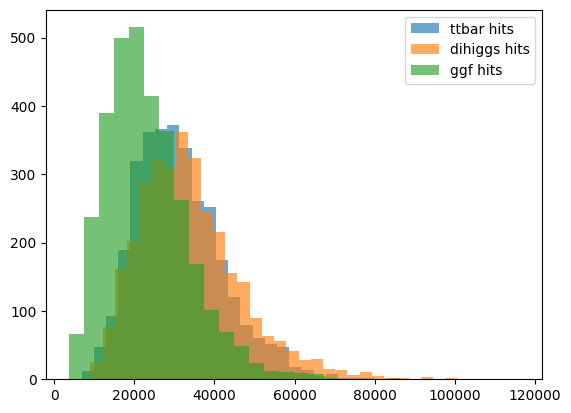

In [14]:
plt.figure()
plt.hist(num_hits_ttbar, bins=30, alpha=0.65, label='ttbar hits')
plt.hist(num_hits_dihiggs, bins=30, alpha=0.65, label ='dihiggs hits')
plt.hist(num_hits_ggf, bins=30, alpha=0.65, label='ggf hits')
plt.legend()
plt.show()

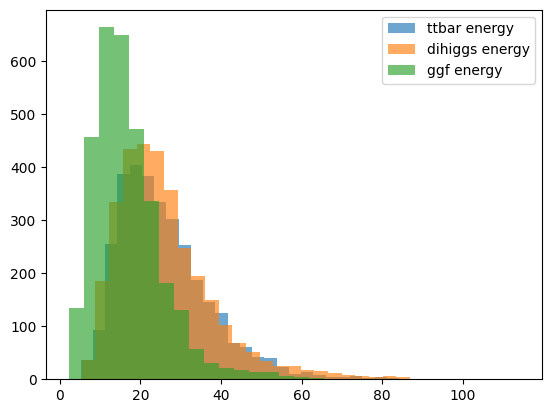

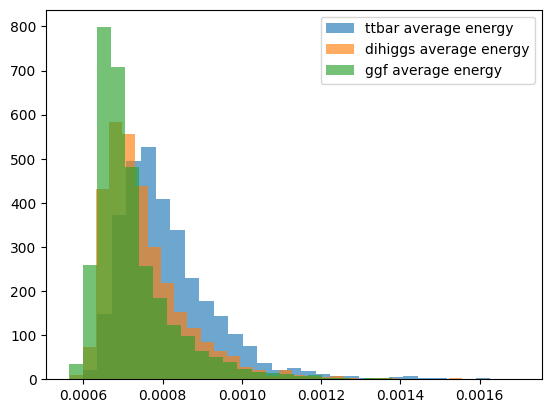

In [21]:
en_hits_ttbar = [np.sum(hits["calo_hit_features"][:,3]) for hits in hits_ttbar]
en_hits_dihiggs = [np.sum(hits["calo_hit_features"][:,3]) for hits in hits_dihiggs]
en_hits_ggf = [np.sum(hits["calo_hit_features"][:,3]) for hits in hits_ggf]

plt.figure()
plt.hist(en_hits_ttbar, bins=30, alpha=0.65, label='ttbar energy')
plt.hist(en_hits_dihiggs, bins=30, alpha=0.65, label ='dihiggs energy')
plt.hist(en_hits_ggf, bins=30, alpha=0.65, label='ggf energy')
plt.legend()
plt.show()


av_en_hits_ttbar = [np.mean(hits["calo_hit_features"][:,3]) for hits in hits_ttbar]
av_en_hits_dihiggs = [np.mean(hits["calo_hit_features"][:,3]) for hits in hits_dihiggs]
av_en_hits_ggf = [np.mean(hits["calo_hit_features"][:,3]) for hits in hits_ggf]

plt.figure()
plt.hist(av_en_hits_ttbar, bins=30, alpha=0.65, label='ttbar average energy')
plt.hist(av_en_hits_dihiggs, bins=30, alpha=0.65, label ='dihiggs average energy')
plt.hist(av_en_hits_ggf, bins=30, alpha=0.65, label='ggf average energy')
plt.legend()
plt.show()

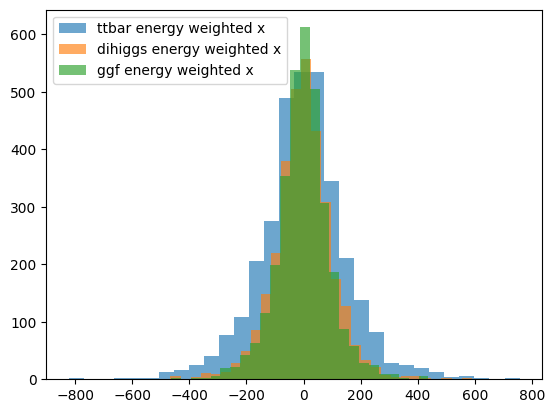

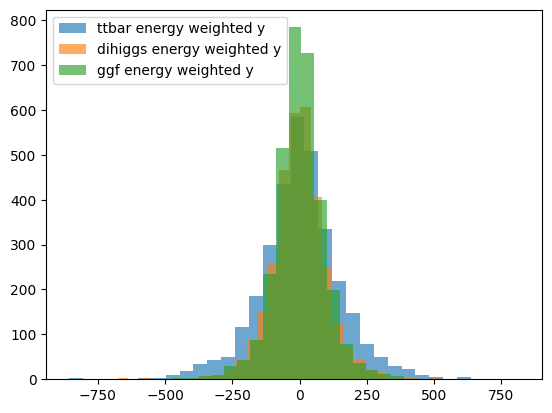

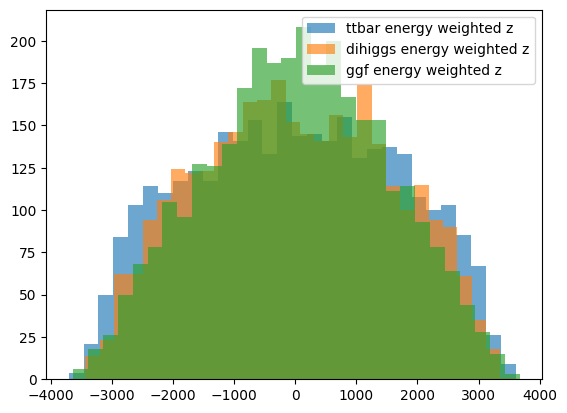

In [22]:
x_hits_ttbar = [np.dot(hits["calo_hit_features"][:,3],hits["calo_hit_features"][:,0])/np.sum(hits["calo_hit_features"][:,3]) for hits in hits_ttbar]
x_hits_dihiggs = [np.dot(hits["calo_hit_features"][:,3],hits["calo_hit_features"][:,0])/np.sum(hits["calo_hit_features"][:,3]) for hits in hits_dihiggs]
x_hits_ggf = [np.dot(hits["calo_hit_features"][:,3],hits["calo_hit_features"][:,0])/np.sum(hits["calo_hit_features"][:,3]) for hits in hits_ggf]

plt.figure()
plt.hist(x_hits_ttbar, bins=30, alpha=0.65, label='ttbar energy weighted x')
plt.hist(x_hits_dihiggs, bins=30, alpha=0.65, label ='dihiggs energy weighted x')
plt.hist(x_hits_ggf, bins=30, alpha=0.65, label='ggf energy weighted x')
plt.legend()
plt.show()


y_hits_ttbar = [np.dot(hits["calo_hit_features"][:,3],hits["calo_hit_features"][:,1])/np.sum(hits["calo_hit_features"][:,3]) for hits in hits_ttbar]
y_hits_dihiggs = [np.dot(hits["calo_hit_features"][:,3],hits["calo_hit_features"][:,1])/np.sum(hits["calo_hit_features"][:,3]) for hits in hits_dihiggs]
y_hits_ggf = [np.dot(hits["calo_hit_features"][:,3],hits["calo_hit_features"][:,1])/np.sum(hits["calo_hit_features"][:,3]) for hits in hits_ggf]

plt.figure()
plt.hist(y_hits_ttbar, bins=30, alpha=0.65, label='ttbar energy weighted y')
plt.hist(y_hits_dihiggs, bins=30, alpha=0.65, label ='dihiggs energy weighted y')
plt.hist(y_hits_ggf, bins=30, alpha=0.65, label='ggf energy weighted y')
plt.legend()
plt.show()


z_hits_ttbar = [np.dot(hits["calo_hit_features"][:,3],hits["calo_hit_features"][:,2])/np.sum(hits["calo_hit_features"][:,3]) for hits in hits_ttbar]
z_hits_dihiggs = [np.dot(hits["calo_hit_features"][:,3],hits["calo_hit_features"][:,2])/np.sum(hits["calo_hit_features"][:,3]) for hits in hits_dihiggs]
z_hits_ggf = [np.dot(hits["calo_hit_features"][:,3],hits["calo_hit_features"][:,2])/np.sum(hits["calo_hit_features"][:,3]) for hits in hits_ggf]

plt.figure()
plt.hist(z_hits_ttbar, bins=30, alpha=0.65, label='ttbar energy weighted z')
plt.hist(z_hits_dihiggs, bins=30, alpha=0.65, label ='dihiggs energy weighted z')
plt.hist(z_hits_ggf, bins=30, alpha=0.65, label='ggf energy weighted z')
plt.legend()
plt.show()

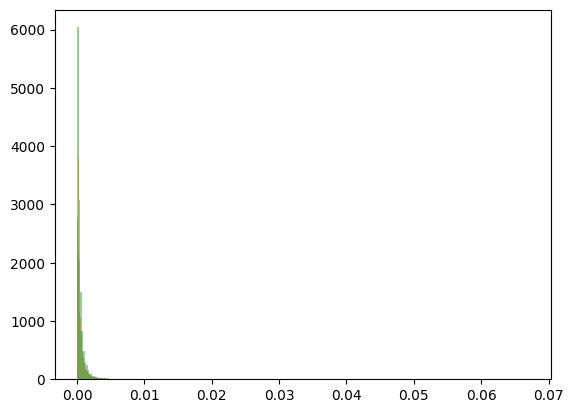

In [31]:
for hits in hits_ttbar:
    en_ttbar = hits["calo_hit_features"][:,3]

    
    break

for hits in hits_dihiggs:
    en_dihiggs = hits["calo_hit_features"][:,3]


    break

for hits in hits_ggf:
    en_ggf = hits["calo_hit_features"][:,3]


    break

plt.figure()
plt.hist(en_ttbar,bins=300, alpha=0.5)
plt.hist(en_dihiggs,bins=300, alpha=0.5)
plt.hist(en_ggf,bins=300, alpha=0.5)
plt.show()

